# 🎯 Confidence Score Calibration Demo

<div style="background-color: rgba(200, 200, 200, 0.1); padding: 20px; border-radius: 8px; margin-bottom: 20px; border: 1px solid rgba(127, 127, 127, 0.2); max-width: 97.5%; overflow-wrap: break-word;">
  <p style="font-size: 16px; line-height: 1.6">
     Confidence scores from uncertainty quantification methods may not be well-calibrated probabilities. This demo demonstrates how to transform raw confidence scores into calibrated probabilities that better reflect the true likelihood of correctness using the <code>ScoreCalibrator</code> class.
  </p>
</div>

## 📊 What You'll Do in This Demo

<div style="display: flex; margin-bottom: 15px; align-items: center">
  <div style="background-color: #34a853; color: white; border-radius: 50%; width: 30px; height: 30px; display: flex; justify-content: center; align-items: center; margin-right: 15px; flex-shrink: 0"><strong>1</strong></div>
  <div>
    <p style="margin: 0; font-weight: bold">Generate simulated confidence scores and correctness labels</p>
    <p style="margin: 0; color: rgba(95, 99, 104, 0.8)">Create realistic example data that mimics UQ results with varying calibration quality.</p>
  </div>
</div>

<div style="display: flex; margin-bottom: 15px; align-items: center">
  <div style="background-color: #34a853; color: white; border-radius: 50%; width: 30px; height: 30px; display: flex; justify-content: center; align-items: center; margin-right: 15px; flex-shrink: 0"><strong>2</strong></div>
  <div>
    <p style="margin: 0; font-weight: bold">Compare calibration methods</p>
    <p style="margin: 0; color: rgba(95, 99, 104, 0.8)">Evaluate uncalibrated scores vs Platt scaling vs Isotonic regression.</p>
  </div>
</div>

<div style="display: flex; margin-bottom: 25px; align-items: center">
  <div style="background-color: #34a853; color: white; border-radius: 50%; width: 30px; height: 30px; display: flex; justify-content: center; align-items: center; margin-right: 15px; flex-shrink: 0"><strong>3</strong></div>
  <div>
    <p style="margin: 0; font-weight: bold">Visualize calibration quality</p>
    <p style="margin: 0; color: rgba(95, 99, 104, 0.8)">Generate reliability diagrams and compute calibration metrics like ECE and Brier score.</p>
  </div>
</div>

## ⚖️ Calibration Methods

<div style="display: flex; gap: 20px">
  <div style="flex: 1; background-color: rgba(0, 100, 200, 0.1); padding: 15px; border-radius: 8px; border: 1px solid rgba(0, 100, 200, 0.2)">
    <h3 style="color: #1e40af; margin-top: 0">Platt Scaling</h3>
    <ul style="margin-bottom: 0">
      <li><strong>Method:</strong> Logistic regression</li>
      <li><strong>Parametric:</strong> Assumes sigmoid-shaped calibration function</li>
      <li><strong>Best for:</strong> Small datasets, well-behaved score distributions</li>
    </ul>
  </div>
  
  <div style="flex: 1; background-color: rgba(0, 200, 0, 0.1); padding: 15px; border-radius: 8px; border: 1px solid rgba(0, 200, 0, 0.2)">
    <h3 style="color: #2e8b57; margin-top: 0">Isotonic Regression</h3>
    <ul style="margin-bottom: 0">
      <li><strong>Method:</strong> Non-parametric, monotonic</li>
      <li><strong>Flexible:</strong> Can handle any monotonic calibration curve</li>
      <li><strong>Best for:</strong> Larger datasets, complex score distributions</li>
    </ul>
  </div>
</div>

In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

from uqlm.utils.calibrators import ScoreCalibrator, compare_calibration_methods
from uqlm.utils import load_example_dataset, Tuner

## 1. Generate Simulated Data

For this demo, we'll create simulated confidence scores that mimic real UQ results. We'll generate scores with different levels of calibration quality to demonstrate the calibration methods.

In [2]:
# Set random seed for reproducibility
np.random.seed(42)
n_samples = 1000

# Load example dataset for prompts/answers (optional, for context)
gsm8k = load_example_dataset("gsm8k", n=n_samples)
print(f"Loaded {len(gsm8k)} questions from GSM8K dataset")

# Generate simulated confidence scores with poor calibration characteristics
# Overconfident scores - this mimics a common problem where UQ methods
# produce confidence scores that are systematically too high
overconfident_probs = np.random.beta(0.5, 0.5, n_samples)
overconfident_probs = 0.3 + 0.7 * overconfident_probs
response_correct = np.random.binomial(1, 0.2 + 0.4 * overconfident_probs)

# Create DataFrame
data = {"prompt": gsm8k.question[:n_samples], "response": [f"Response {i}" for i in range(n_samples)], "confidence_score": overconfident_probs, "correct": response_correct.astype(bool), "answer": gsm8k.answer[:n_samples]}

df = pd.DataFrame(data)
print(f"Generated {len(df)} samples with overconfident scores")
print(f"Mean confidence score: {np.mean(df['confidence_score']):.3f}")
print(f"Actual accuracy: {np.mean(df['correct']):.3f}")
print(f"Calibration gap: {np.mean(df['confidence_score']) - np.mean(df['correct']):.3f}")
df.head()

Using the latest cached version of the dataset since openai/gsm8k couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'main' at /Users/jmabry/.cache/huggingface/datasets/openai___gsm8k/main/0.0.0/e53f048856ff4f594e959d75785d2c2d37b678ee (last modified on Fri Aug 15 10:46:30 2025).


Loading dataset - gsm8k...
Processing dataset...
Dataset ready!
Loaded 1000 questions from GSM8K dataset
Generated 1000 samples with overconfident scores
Mean confidence score: 0.634
Actual accuracy: 0.445
Calibration gap: 0.189


,prompt,response,confidence_score,correct,answer
0,Natalia sold clips to 48 of her friends in Apr...,Response 0,0.719445,True,72
1,Weng earns $12 an hour for babysitting. Yester...,Response 1,0.650054,True,10
2,Betty is saving money for a new wallet which c...,Response 2,0.303134,False,5
3,"Julie is reading a 120-page book. Yesterday, s...",Response 3,0.593191,False,42
4,James writes a 3-page letter to 2 different fr...,Response 4,0.300315,True,624


## 2. Split Data for Calibration Training/Testing

For proper calibration evaluation, we split the data into training and testing sets. The calibrators will be trained on the training set and evaluated on the test set.

In [3]:
# Split data for training/testing calibration
split_idx = len(df) // 2
train_df = df.iloc[:split_idx]
test_df = df.iloc[split_idx:]

print(f"Split data: {len(train_df)} training, {len(test_df)} testing samples")

Split data: 500 training, 500 testing samples


## 3. Compare Calibration Methods

We'll compare three approaches for each scorer:
- **Uncalibrated**: Using raw confidence scores
- **Platt Scaling**: Logistic regression-based calibration  
- **Isotonic Regression**: Non-parametric, monotonic calibration

In [4]:
print("=== Calibration Method Comparison ===")
comparison = compare_calibration_methods(scores=train_df["confidence_score"], correct_labels=train_df["correct"], test_scores=test_df["confidence_score"], test_correct_labels=test_df["correct"])
print(comparison.round(4))
print("\nKey metrics:")
print("- Lower Brier score = better")
print("- Lower ECE (Expected Calibration Error) = better calibration")
print("- Lower MCE (Maximum Calibration Error) = better calibration")

=== Calibration Method Comparison ===
              brier_score  log_loss     ece     mce
method                                             
uncalibrated       0.3179    1.0594  0.2360  0.4544
platt              0.2432    0.6793  0.0354  0.0831
isotonic           0.2459    0.6870  0.0717  0.3750

Key metrics:
- Lower Brier score = better
- Lower ECE (Expected Calibration Error) = better calibration
- Lower MCE (Maximum Calibration Error) = better calibration


## 4. Apply Calibration to Test Data

Now we'll train calibrators on the training set and apply them to the test set to get calibrated confidence scores.

In [5]:
print("=== Applying Calibration Methods ===")

# Train Platt scaling calibrator
platt_calibrator = ScoreCalibrator(method="platt")
platt_calibrator.fit(train_df["confidence_score"], train_df["correct"])

# Train Isotonic regression calibrator
isotonic_calibrator = ScoreCalibrator(method="isotonic")
isotonic_calibrator.fit(train_df["confidence_score"], train_df["correct"])

# Apply to test set
test_df_calibrated = test_df.copy()
test_df_calibrated["confidence_score_platt"] = platt_calibrator.transform(test_df["confidence_score"])
test_df_calibrated["confidence_score_isotonic"] = isotonic_calibrator.transform(test_df["confidence_score"])

print("Applied Platt and Isotonic calibration to confidence scores")

print("\nCalibrated scores summary:")
calibration_cols = ["confidence_score", "confidence_score_platt", "confidence_score_isotonic"]
print(test_df_calibrated[calibration_cols].describe().round(3))

=== Applying Calibration Methods ===
Applied Platt and Isotonic calibration to confidence scores

Calibrated scores summary:
       confidence_score  confidence_score_platt  confidence_score_isotonic
count           500.000                 500.000                    500.000
mean              0.640                   0.462                      0.468
std               0.246                   0.092                      0.120
min               0.300                   0.336                      0.211
25%               0.393                   0.369                      0.366
50%               0.631                   0.458                      0.500
75%               0.878                   0.553                      0.500
max               1.000                   0.598                      0.875


## 5. Evaluate Calibration Quality

We'll evaluate the calibration quality using reliability diagrams and calibration metrics like Expected Calibration Error (ECE) and Brier score.

Calibration Quality Evaluation

🔵 BEFORE CALIBRATION (Original Scores):


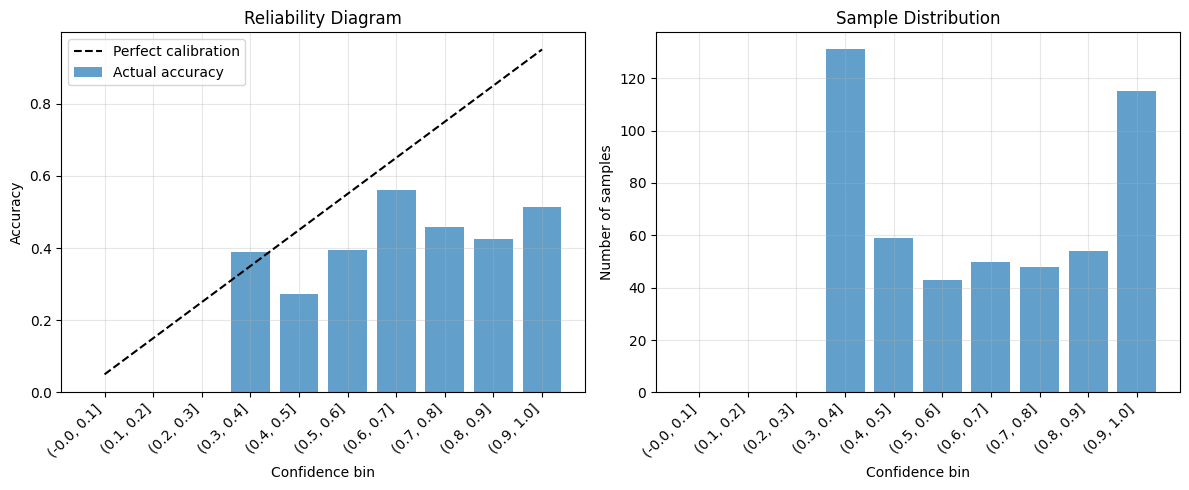


🟢 AFTER PLATT SCALING:


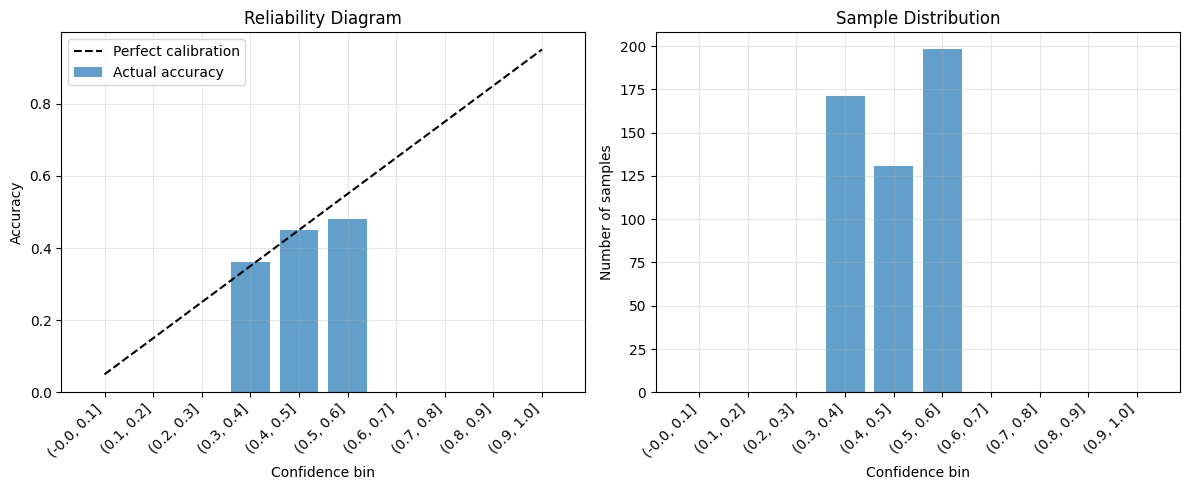


🟡 AFTER ISOTONIC REGRESSION:


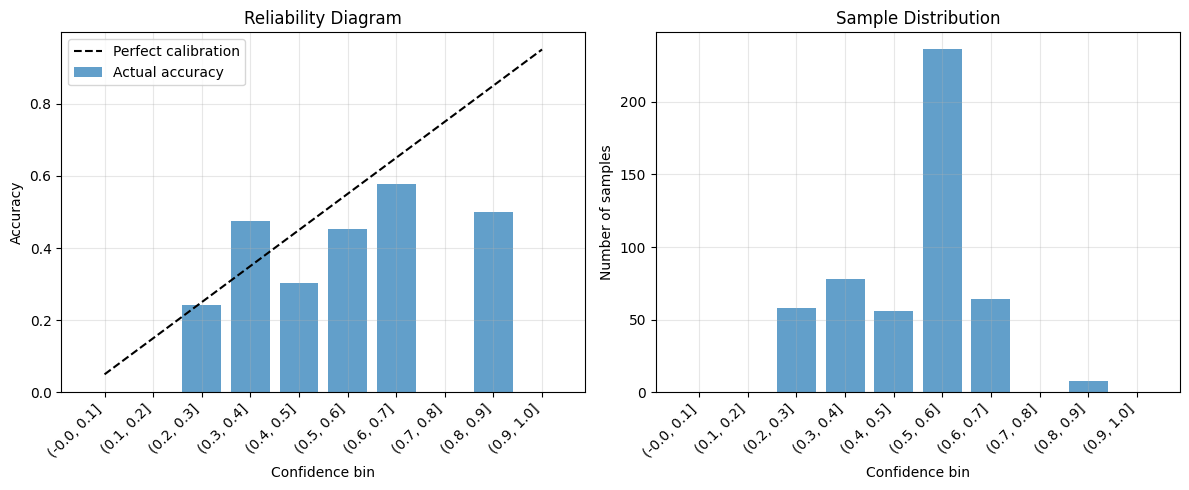


📊 CALIBRATION IMPROVEMENT SUMMARY:
ECE: 0.2360 → 0.0354 (Platt) | 0.0717 (Isotonic)
Brier: 0.3179 → 0.2432 (Platt) | 0.2459 (Isotonic)
MCE: 0.4544 → 0.0831 (Platt) | 0.3750 (Isotonic)


In [6]:
print(f"{'=' * 60}")
print("Calibration Quality Evaluation")
print(f"{'=' * 60}")

# Original scores
print("\n🔵 BEFORE CALIBRATION (Original Scores):")
calibrator = ScoreCalibrator()
original_metrics = calibrator.evaluate_calibration(test_df_calibrated["confidence_score"], test_df_calibrated["correct"], plot=True)

# Platt scaling
print("\n🟢 AFTER PLATT SCALING:")
platt_metrics = calibrator.evaluate_calibration(test_df_calibrated["confidence_score_platt"], test_df_calibrated["correct"], plot=True)

# Isotonic regression
print("\n🟡 AFTER ISOTONIC REGRESSION:")
isotonic_metrics = calibrator.evaluate_calibration(test_df_calibrated["confidence_score_isotonic"], test_df_calibrated["correct"], plot=True)

# Summary
print("\n📊 CALIBRATION IMPROVEMENT SUMMARY:")
print(f"ECE: {original_metrics['ece']:.4f} → {platt_metrics['ece']:.4f} (Platt) | {isotonic_metrics['ece']:.4f} (Isotonic)")
print(f"Brier: {original_metrics['brier_score']:.4f} → {platt_metrics['brier_score']:.4f} (Platt) | {isotonic_metrics['brier_score']:.4f} (Isotonic)")
print(f"MCE: {original_metrics['mce']:.4f} → {platt_metrics['mce']:.4f} (Platt) | {isotonic_metrics['mce']:.4f} (Isotonic)")

## 6. Hallucination Detection Performance

Finally, let's evaluate how calibration affects hallucination detection performance by comparing F1-scores before and after calibration.

In [7]:
# Evaluate all scorers (original + calibrated)
all_scorers = ["confidence_score", "confidence_score_platt", "confidence_score_isotonic"]

t = Tuner()
results_comparison = []

for scorer in all_scorers:
    y_scores = test_df_calibrated[scorer].values
    correct_indicators = test_df_calibrated["correct"].values

    # Find optimal threshold
    best_threshold = t.tune_threshold(y_scores=y_scores, correct_indicators=correct_indicators, thresh_objective="fbeta_score")

    # Make predictions
    y_pred = (y_scores > best_threshold).astype(int)

    # Calculate metrics
    precision = precision_score(y_true=correct_indicators, y_pred=y_pred)
    recall = recall_score(y_true=correct_indicators, y_pred=y_pred)
    f1 = f1_score(y_true=correct_indicators, y_pred=y_pred)

    results_comparison.append({"scorer": scorer, "threshold": best_threshold, "precision": precision, "recall": recall, "f1_score": f1})

# Convert to DataFrame for better display
comparison_df = pd.DataFrame(results_comparison)
print("Hallucination Detection Performance Comparison:")
print("=" * 80)
print(comparison_df.round(4))

# Summary by method
print("\n📈 F1-Score Comparison by Calibration Method:")
print("-" * 50)
for _, row in comparison_df.iterrows():
    if row["scorer"] == "confidence_score":
        method = "Original (Uncalibrated)"
    elif "platt" in row["scorer"]:
        method = "Platt Scaling"
    else:
        method = "Isotonic Regression"
    print(f"  {method}: F1 = {row['f1_score']:.4f}")

# Show improvement
original_f1 = comparison_df[comparison_df["scorer"] == "confidence_score"]["f1_score"].iloc[0]
platt_f1 = comparison_df[comparison_df["scorer"] == "confidence_score_platt"]["f1_score"].iloc[0]
isotonic_f1 = comparison_df[comparison_df["scorer"] == "confidence_score_isotonic"]["f1_score"].iloc[0]

print("\nF1-Score Improvement:")
print(f"  Platt vs Original: {platt_f1 - original_f1:+.4f}")
print(f"  Isotonic vs Original: {isotonic_f1 - original_f1:+.4f}")

Hallucination Detection Performance Comparison:
                      scorer  threshold  precision  recall  f1_score
0           confidence_score       0.32     0.4539  0.9352    0.6112
1     confidence_score_platt       0.35     0.4586  0.8981    0.6072
2  confidence_score_isotonic       0.29     0.4570  0.9352    0.6140

📈 F1-Score Comparison by Calibration Method:
--------------------------------------------------
  Original (Uncalibrated): F1 = 0.6112
  Platt Scaling: F1 = 0.6072
  Isotonic Regression: F1 = 0.6140

F1-Score Improvement:
  Platt vs Original: -0.0040
  Isotonic vs Original: +0.0028


## 7. Summary

This calibration analysis demonstrates:

### 🎯 **Key Findings**

1. **Calibration Quality**: Use reliability diagrams and metrics like ECE and Brier score to assess how well confidence scores reflect true probabilities

2. **Method Selection**: 
   - **Platt Scaling** works well for smaller datasets and when the calibration curve is roughly sigmoid-shaped
   - **Isotonic Regression** is more flexible and can handle complex, non-parametric calibration curves

3. **Practical Impact**: Calibration can significantly improve:
   - Reliability of confidence scores for decision-making
   - Performance in downstream tasks like hallucination detection
   - User trust in model predictions

### 🔧 **Using ScoreCalibrator**

The `ScoreCalibrator` class provides a simple interface:

```python
# Basic usage
calibrator = ScoreCalibrator(method="platt")  # or "isotonic"
calibrator.fit(train_scores, train_labels)
calibrated_scores = calibrator.transform(test_scores)

# Evaluation
metrics = calibrator.evaluate_calibration(scores, labels, plot=True)
```

### 📚 **Next Steps**

- Apply calibration to your own UQ results using `calibrate_uq_results()`
- Experiment with both Platt and Isotonic methods on your data
- Use reliability diagrams to visualize calibration quality
- Integrate calibrated scores into your decision-making pipeline

---

© 2025 CVS Health and/or one of its affiliates. All rights reserved.

## 5.5. Understanding Calibration Effects: Why Similar Thresholds?

Let's investigate why the optimal thresholds remain similar after calibration and why the performance improvements are minimal.

🔍 CALIBRATION TRANSFORMATION ANALYSIS


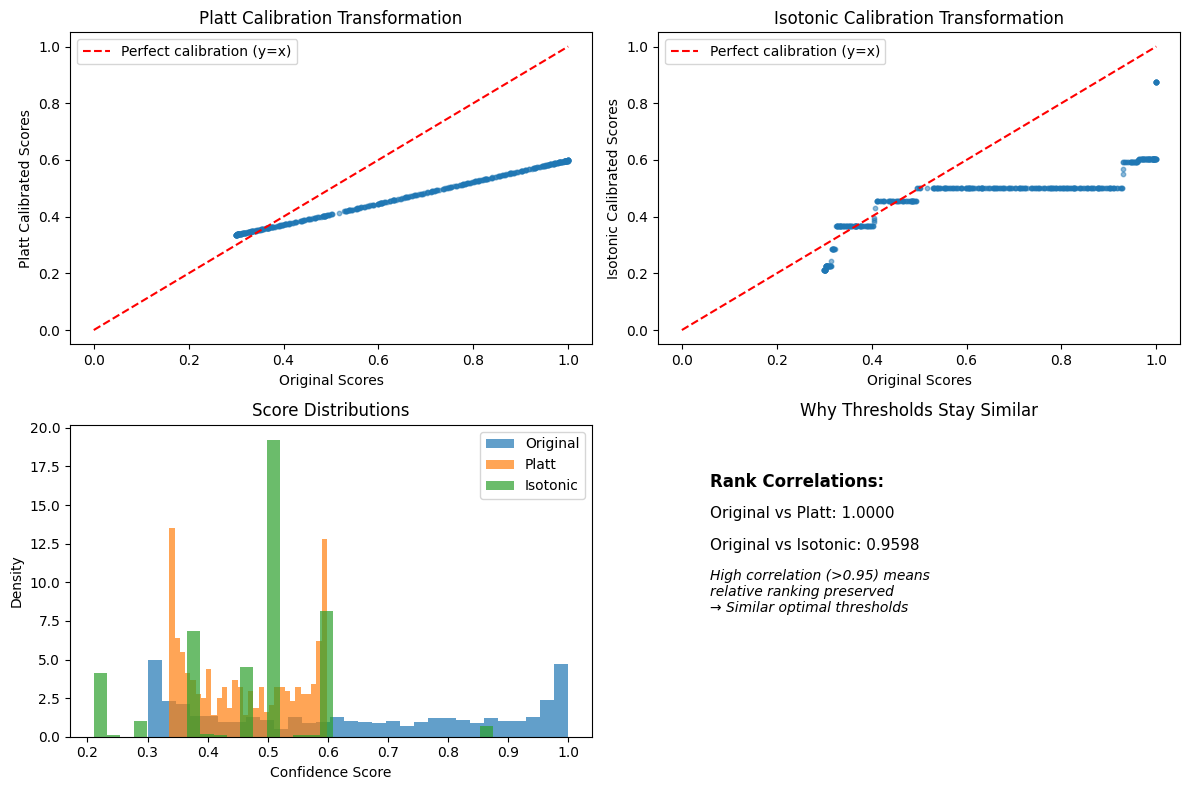


📊 SCORE STATISTICS:
Original scores: mean=0.640, std=0.246
Platt scores:    mean=0.462, std=0.092
Isotonic scores: mean=0.468, std=0.120

🔄 RANK PRESERVATION:
Spearman correlation (Original vs Platt): 1.0000
Spearman correlation (Original vs Isotonic): 0.9598


In [10]:
import matplotlib.pyplot as plt

print("🔍 CALIBRATION TRANSFORMATION ANALYSIS")
print("=" * 60)

# Analyze the calibration transformation
original_scores = test_df_calibrated["confidence_score"]
platt_scores = test_df_calibrated["confidence_score_platt"]
isotonic_scores = test_df_calibrated["confidence_score_isotonic"]

# Score distribution comparison
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Original vs Platt
axes[0, 0].scatter(original_scores, platt_scores, alpha=0.5, s=10)
axes[0, 0].plot([0, 1], [0, 1], "r--", label="Perfect calibration (y=x)")
axes[0, 0].set_xlabel("Original Scores")
axes[0, 0].set_ylabel("Platt Calibrated Scores")
axes[0, 0].set_title("Platt Calibration Transformation")
axes[0, 0].legend()

# Original vs Isotonic
axes[0, 1].scatter(original_scores, isotonic_scores, alpha=0.5, s=10)
axes[0, 1].plot([0, 1], [0, 1], "r--", label="Perfect calibration (y=x)")
axes[0, 1].set_xlabel("Original Scores")
axes[0, 1].set_ylabel("Isotonic Calibrated Scores")
axes[0, 1].set_title("Isotonic Calibration Transformation")
axes[0, 1].legend()

# Score distributions
axes[1, 0].hist(original_scores, bins=30, alpha=0.7, label="Original", density=True)
axes[1, 0].hist(platt_scores, bins=30, alpha=0.7, label="Platt", density=True)
axes[1, 0].hist(isotonic_scores, bins=30, alpha=0.7, label="Isotonic", density=True)
axes[1, 0].set_xlabel("Confidence Score")
axes[1, 0].set_ylabel("Density")
axes[1, 0].set_title("Score Distributions")
axes[1, 0].legend()

# Rank correlation analysis
from scipy.stats import spearmanr

spearman_platt = spearmanr(original_scores, platt_scores)[0]
spearman_isotonic = spearmanr(original_scores, isotonic_scores)[0]

axes[1, 1].text(0.1, 0.8, "Rank Correlations:", fontsize=12, fontweight="bold", transform=axes[1, 1].transAxes)
axes[1, 1].text(0.1, 0.7, f"Original vs Platt: {spearman_platt:.4f}", fontsize=11, transform=axes[1, 1].transAxes)
axes[1, 1].text(0.1, 0.6, f"Original vs Isotonic: {spearman_isotonic:.4f}", fontsize=11, transform=axes[1, 1].transAxes)
axes[1, 1].text(0.1, 0.4, "High correlation (>0.95) means\nrelative ranking preserved\n→ Similar optimal thresholds", fontsize=10, transform=axes[1, 1].transAxes, style="italic")
axes[1, 1].set_xlim(0, 1)
axes[1, 1].set_ylim(0, 1)
axes[1, 1].set_title("Why Thresholds Stay Similar")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

print("\n📊 SCORE STATISTICS:")
print(f"Original scores: mean={np.mean(original_scores):.3f}, std={np.std(original_scores):.3f}")
print(f"Platt scores:    mean={np.mean(platt_scores):.3f}, std={np.std(platt_scores):.3f}")
print(f"Isotonic scores: mean={np.mean(isotonic_scores):.3f}, std={np.std(isotonic_scores):.3f}")

print("\n🔄 RANK PRESERVATION:")
print(f"Spearman correlation (Original vs Platt): {spearman_platt:.4f}")
print(f"Spearman correlation (Original vs Isotonic): {spearman_isotonic:.4f}")

## 5.6. Why Calibration Preserves Optimal Thresholds

The key insight is that **calibration primarily affects the scale/range of scores, not their relative ranking**. Here's why:

### 🎯 **Threshold Preservation Explained**

1. **Rank Correlation**: If calibrated scores have high rank correlation (>0.95) with original scores, the relative ordering is preserved
2. **Monotonic Transformation**: Both Platt and Isotonic are monotonic - they preserve the ordering of confidence scores
3. **F1 Optimization**: F1-score depends on ranking decisions (precision/recall trade-off), not absolute probability values

### 📈 **When Calibration Changes Thresholds**

Thresholds would change significantly if:
- Original scores had poor ranking quality (low discriminative ability)
- Calibration dramatically compressed/expanded certain score ranges
- The calibration transformation was highly non-linear in critical threshold regions

In [12]:
print("🎯 CALIBRATION IMPACT ANALYSIS")
print("=" * 50)


# Analyze why minimal performance improvement
def analyze_calibration_impact(original, calibrated, correct, method_name):
    print(f"\n{method_name.upper()} ANALYSIS:")

    # Check if transformation is approximately linear
    from scipy.stats import pearsonr

    pearson_r = pearsonr(original, calibrated)[0]

    # Analyze score ranges
    orig_range = np.max(original) - np.min(original)
    cal_range = np.max(calibrated) - np.min(calibrated)

    # Check calibration quality improvement
    from sklearn.calibration import calibration_curve

    orig_frac_pos, orig_mean_pred = calibration_curve(correct, original, n_bins=10)
    cal_frac_pos, cal_mean_pred = calibration_curve(correct, calibrated, n_bins=10)

    orig_cal_error = np.mean(np.abs(orig_frac_pos - orig_mean_pred))
    cal_cal_error = np.mean(np.abs(cal_frac_pos - cal_mean_pred))

    print(f"  Pearson correlation: {pearson_r:.4f} {'(nearly linear)' if pearson_r > 0.98 else '(non-linear)'}")
    print(f"  Score range change: {orig_range:.3f} → {cal_range:.3f} ({cal_range / orig_range:.2f}x)")
    print(f"  Calibration error: {orig_cal_error:.4f} → {cal_cal_error:.4f} ({cal_cal_error - orig_cal_error:+.4f})")

    # If nearly linear transformation, explain threshold preservation
    if pearson_r > 0.98:
        print("  ⚠️  Nearly linear transformation → ranking preserved → similar optimal thresholds")

    return pearson_r, cal_cal_error - orig_cal_error


comparison = compare_calibration_methods(scores=train_df["confidence_score"], correct_labels=train_df["correct"], test_scores=test_df["confidence_score"], test_correct_labels=test_df["correct"])

platt_linearity, platt_cal_improvement = analyze_calibration_impact(test_df["confidence_score"], platt_scores, test_df_calibrated["correct"], "Platt")

isotonic_linearity, isotonic_cal_improvement = analyze_calibration_impact(original_scores, isotonic_scores, test_df_calibrated["correct"], "Isotonic")

print("\n💡 KEY INSIGHTS:")
print(f"   1. High rank correlation ({spearman_platt:.3f}, {spearman_isotonic:.3f}) preserves optimal thresholds")
print("   2. Calibration improves probability estimates, not necessarily classification performance")
print("   3. For better F1 improvements, you'd need scores with poor initial ranking quality")

# Show what would happen with poorly ranked scores
print("\n🔬 SIMULATION: What if original scores had poor ranking?")
# Create poorly ranked scores (random + small signal)
poor_scores = 0.7 * np.random.random(len(test_df_calibrated)) + 0.1 * test_df_calibrated["confidence_score"]
poor_correlation = spearmanr(poor_scores, test_df_calibrated["correct"])[0]
good_correlation = spearmanr(original_scores, test_df_calibrated["correct"])[0]

print(f"   Original scores correlation with correctness: {good_correlation:.3f}")
print(f"   Poor ranking scores correlation: {poor_correlation:.3f}")
print("   → Calibration would have larger impact on poor ranking scores")

🎯 CALIBRATION IMPACT ANALYSIS

PLATT ANALYSIS:
  Pearson correlation: 0.9999 (nearly linear)
  Score range change: 0.700 → 0.262 (0.37x)
  Calibration error: 0.2358 → 0.0304 (-0.2054)
  ⚠️  Nearly linear transformation → ranking preserved → similar optimal thresholds

ISOTONIC ANALYSIS:
  Pearson correlation: 0.8567 (non-linear)
  Score range change: 0.700 → 0.664 (0.95x)
  Calibration error: 0.2358 → 0.1218 (-0.1140)

💡 KEY INSIGHTS:
   1. High rank correlation (1.000, 0.960) preserves optimal thresholds
   2. Calibration improves probability estimates, not necessarily classification performance
   3. For better F1 improvements, you'd need scores with poor initial ranking quality

🔬 SIMULATION: What if original scores had poor ranking?
   Original scores correlation with correctness: 0.134
   Poor ranking scores correlation: 0.022
   → Calibration would have larger impact on poor ranking scores
